# Introduktion

Syftet med denna analys är att utforska housing-datasetet och identifiera mönster, samband och eventuella problem i datan.

I analysen kommer följande att undersökas:

- Datasetets struktur och innehåll
- Saknade värden
- Beskrivande statistik
- Fördelningen av viktiga variabler
- Samband mellan olika variabler
- Hur geografiskt läge påverkar bostadspriser

Målet är att skapa en bättre förståelse för vilka faktorer som verkar påverka bostadsvärdena i datasetet.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

houses = pd.read_csv('housing.csv')

In [2]:
houses.shape

(20640, 10)

In [3]:
houses.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
houses.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Dataöversikt

För att få en första förståelse för datan undersöks datasetets storlek, datatyper och de första observationerna.

Informationen visar:

- Antal rader och kolumner
- Vilka variabler som finns tillgängliga
- Datatyper för respektive variabel
- Exempel på hur datan är strukturerad

Datasetet innehåller 20 640 observationer och 10 variabler.

De flesta variabler är numeriska medan ocean_proximity är kategorisk och beskriver områdets läge i förhållande till havet.

Detta ger en bra grund för vidare analys av både numeriska och kategoriska variabler.

Denna översikt hjälper till att identifiera vilka variabler som kan vara intressanta att analysera vidare.

In [5]:
houses.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# Beskrivande statistik

Den beskrivande statistiken ger en första överblick över datasetet.

Vi kan se att datasetet innehåller information om bland annat bostadspriser, inkomstnivåer, antal rum och geografisk position.

Det finns stora variationer mellan min- och maxvärden i flera kolumner, vilket tyder på att olika bostadsområden skiljer sig mycket åt.

In [6]:
houses.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

# Saknade värden

Analysen visar att kolumnen total_bedrooms innehåller 207 saknade värden medan övriga kolumner är kompletta.

Saknade värden är viktiga att identifiera eftersom de kan påverka analyser och maskininlärningsmodeller. I detta fall är mängden saknade värden relativt liten jämfört med datasetets totala storlek.

In [7]:
houses.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


# Korrelationsanalys

Korrelationsmatrisen används för att undersöka sambanden mellan de numeriska variablerna.

Särskilt intressant är vilka variabler som har starkast samband med median_house_value eftersom dessa sannolikt påverkar bostadspriserna mest.

Median_income brukar visa ett starkt positivt samband med bostadspriser, vilket undersöks vidare i nästa visualisering.

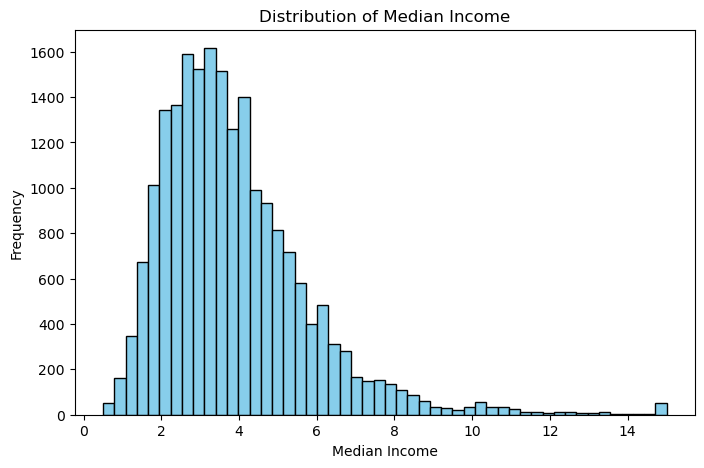

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(houses['median_income'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Median Income')
plt.ylabel('Frequency')
plt.title('Distribution of Median Income')
plt.show()


# Medianinkomst

Histogrammet visar att majoriteten av områdena har en medianinkomst mellan ungefär 2 och 5.

Fördelningen är högerskev vilket innebär att det finns relativt få områden med mycket höga inkomster medan majoriteten ligger på mer normala nivåer.

Det finns även några extremvärden som representerar särskilt välbärgade områden.

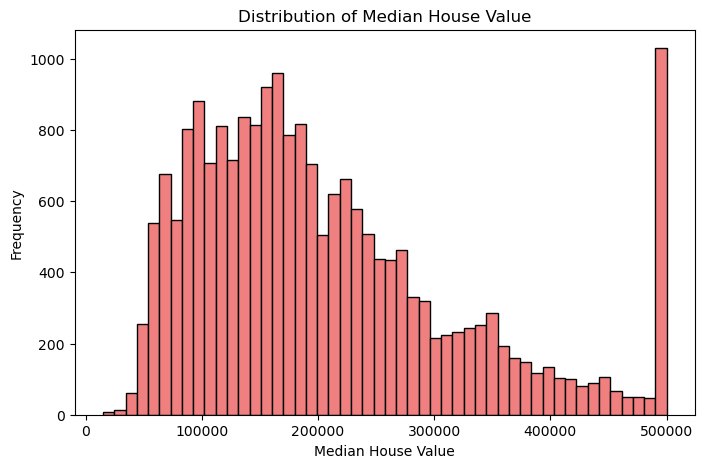

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(houses['median_house_value'], bins=50, color='lightcoral', edgecolor='black')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Value')
plt.show()

# Bostadsvärden

Histogrammet visar hur bostadspriserna är fördelade i datasetet.

De flesta bostadsområden ligger inom ett relativt begränsat prisintervall medan ett mindre antal områden har betydligt högre bostadsvärden.

Fördelningen är inte helt symmetrisk vilket tyder på att vissa områden sticker ut prismässigt.

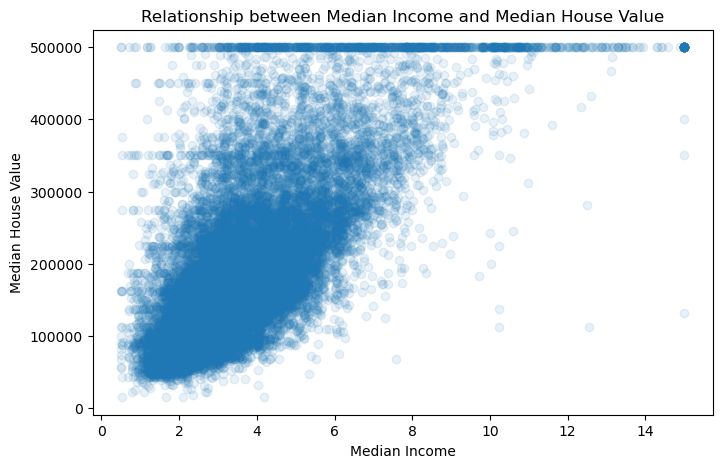

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(houses['median_income'], houses['median_house_value'], alpha=0.1)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Relationship between Median Income and Median House Value')
plt.show()

# Samband mellan medianinkomst och bostadsvärde

Scatterploten visar ett tydligt positivt samband mellan medianinkomst och bostadsvärde.

Områden med högre inkomster tenderar generellt att ha högre bostadspriser.

Detta tyder på att medianinkomst är en av de viktigaste faktorerna för att förklara skillnader i bostadsvärden mellan olika områden.

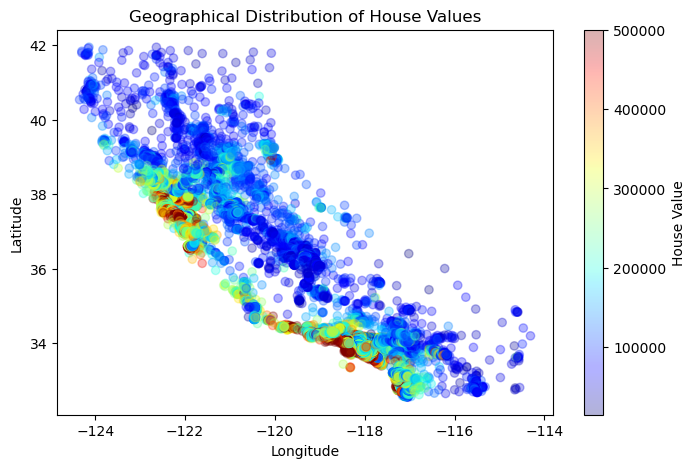

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(houses['longitude'], houses['latitude'], alpha=0.3, c=houses['median_house_value'], cmap='jet')
plt.colorbar(label='House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of House Values')
plt.show()

# Geografisk analys

Visualiseringen visar bostadsområdenas geografiska placering.

Färgerna representerar bostadsvärdet i respektive område.

Det går att se att vissa geografiska områden har betydligt högre bostadsvärden än andra, vilket tyder på att läge spelar en viktig roll för bostadspriset.

<Figure size 1000x500 with 0 Axes>

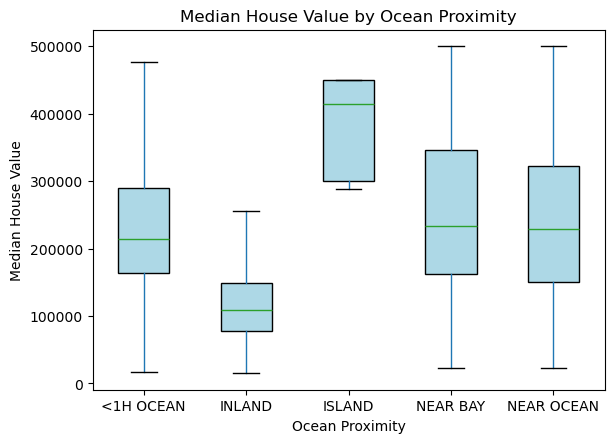

In [12]:
plt.figure(figsize=(10,5))

houses.boxplot(column='median_house_value', by='ocean_proximity', grid=False, showfliers=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))

plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.title('Median House Value by Ocean Proximity')

plt.suptitle('')  # tar bort pandas extra titel

plt.show()

# Havsnära läge och bostadsvärde

Boxploten visar hur bostadsvärden varierar beroende på avstånd till havet.

Det går att se skillnader mellan grupperna, vilket tyder på att geografiskt läge i förhållande till havet påverkar bostadspriserna.

Områden närmare havet tenderar generellt att ha högre bostadsvärden än områden längre från kusten.

# Slutsats

Den utforskande analysen visar att datasetet överlag är av god kvalitet och endast innehåller ett mindre antal saknade värden i kolumnen total_bedrooms.

Analysen visar ett tydligt positivt samband mellan medianinkomst och bostadsvärde, vilket tyder på att inkomstnivån är en viktig faktor för bostadspriser.

Den geografiska analysen visar också att bostädernas läge påverkar värdet. Områden nära kusten tenderar generellt att ha högre bostadspriser än områden längre inåt landet.

Sammanfattningsvis verkar medianinkomst och geografiskt läge vara de två viktigaste faktorerna för att förklara skillnader i bostadsvärden mellan olika områden i datasetet.